In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pickle
import numpy as np

# Load dataset
data = pd.read_csv("data_cleaned.csv")

# Features and target
X = data[['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'ndvi', 'no2', 'pm10']]
y = data['pm2.5']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Load model
model = pickle.load(open("model.pkl", "rb"))

# Reorder X_test columns to match the model's expected feature order
X_test = X_test[model.feature_names_in_]

# Prediction
y_pred = model.predict(X_test)

In [6]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 21.202322456235592
RMSE: 30.6288299085964
R2 Score: 0.7795677673327237


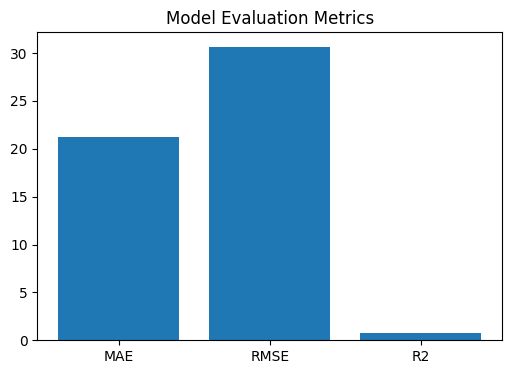

In [8]:
import os

# Plot evaluation metrics
plt.figure(figsize=(6,4))
metrics = ['MAE', 'RMSE', 'R2']
values = [mae, rmse, r2]

plt.bar(metrics, values)
plt.title("Model Evaluation Metrics")

# Create the directory if it doesn't exist
os.makedirs('../images', exist_ok=True)
plt.savefig("../images/evaluation_metrics.png")
plt.show()

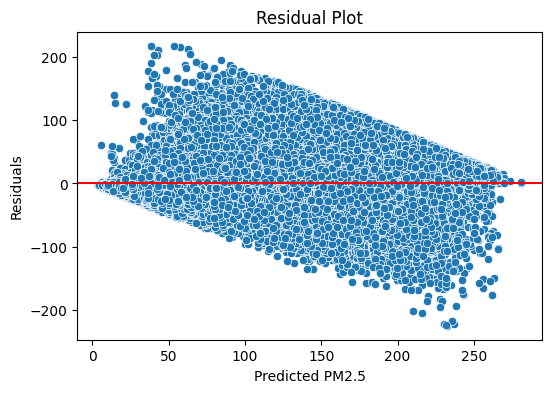

In [9]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("../images/residual_plot.png")
plt.show()